# Project Update 1 — Style vs. Content Decay

This notebook extends the processed Yelp and XSum data with initial stylistic features and T0-relative lexical and semantic retention.

### Goals
1. Extract Type–Token Ratio, sentence length mean/variance, and punctuation frequency.
2. Reuse BLEU/ROUGE and BERTScore results with exact key validation.
3. Compare T0–T3 trajectories for ChatGPT, PaLM, Dipper, and Pegasus.
4. Repeat comparisons on source documents shared by all four paraphrasers.
5. Interpret the figures while treating style measurement as an initial analysis.

> Reusable analysis logic is kept in `src/style_decay.py`.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src/style_decay.py').exists(), 'Run from the repository root or notebooks directory.'
sys.path.insert(0, str(ROOT))
from src.style_decay import main, FEATURES, LEXICAL, SEMANTIC

## 2. Run the Analysis

Only complete Human T0–T3 chains are used. Existing similarity scores are joined by dataset, key, source, paraphraser, and generation; incomplete or duplicate score coverage raises an error.

In [2]:
main(['--root', str(ROOT)])
details = pd.read_csv(ROOT / 'data/results/update1_style_decay_scores.csv')
summary = pd.read_csv(ROOT / 'data/results/update1_style_decay_summary.csv')
matched_summary = pd.read_csv(ROOT / 'data/results/update1_style_decay_matched_summary.csv')
display(summary[['dataset', 'paraphraser', 'generation', 'bertscore_f1_mean', 'style_retention_mean']])

Analyzed 3,718 chains / 14,872 generation rows. Report: docs/update1_style_decay.md


,dataset,paraphraser,generation,bertscore_f1_mean,style_retention_mean
0,xsum,ChatGPT,t0,1.000000,1.000000
1,xsum,ChatGPT,t1,0.885331,0.867219
2,xsum,ChatGPT,t2,0.873535,0.863312
3,xsum,ChatGPT,t3,0.867752,0.859096
4,xsum,Dipper,t0,1.000000,1.000000
5,xsum,Dipper,t1,0.865058,0.886417
6,xsum,Dipper,t2,0.839196,0.874210
7,xsum,Dipper,t3,0.822121,0.866356
8,xsum,PaLM,t0,1.000000,1.000000
9,xsum,PaLM,t1,0.936499,0.910525


## 3. Inspect Features and Relative Changes

Signed change is `(f(Tg) - f(T0)) / f(T0)`. A zero T0 followed by a nonzero value is undefined. Bounded feature retention is `1 - abs(f(Tg)-f(T0)) / (abs(f(Tg))+abs(f(T0)))`, with 1 when both values are zero. The mean of the four retentions is an exploratory style index, not an authorship score.

In [3]:
display(details[['dataset', 'key', 'paraphraser', 'generation'] + FEATURES].head(12))
display(details[[f + '_relative_change' for f in FEATURES]].isna().sum().rename('undefined_change_count'))

,dataset,key,paraphraser,generation,type_token_ratio,sentence_length_mean,sentence_length_variance,punctuation_frequency
0,yelp,yelp-17670,ChatGPT,t0,0.875000,8.000000,1.000000,12.500000
1,yelp,yelp-17670,ChatGPT,t1,0.947368,9.500000,0.250000,10.526316
2,yelp,yelp-17670,ChatGPT,t2,0.956522,11.500000,0.250000,13.043478
3,yelp,yelp-17670,ChatGPT,t3,0.956522,11.500000,2.250000,13.043478
4,yelp,yelp-31827,ChatGPT,t0,0.770115,9.666667,30.222222,13.793103
5,yelp,yelp-31827,ChatGPT,t1,0.744898,14.000000,38.857143,13.265306
6,yelp,yelp-31827,ChatGPT,t2,0.735849,13.250000,44.187500,15.094340
7,yelp,yelp-31827,ChatGPT,t3,0.754902,12.750000,46.187500,15.686275
8,yelp,yelp-31828,ChatGPT,t0,0.875000,32.000000,0.000000,15.625000
9,yelp,yelp-31828,ChatGPT,t1,0.911765,17.000000,0.000000,20.588235


type_token_ratio_relative_change             0
sentence_length_mean_relative_change         0
sentence_length_variance_relative_change    75
punctuation_frequency_relative_change       24
Name: undefined_change_count, dtype: int64

## 4. T0–T3 Decay Curves

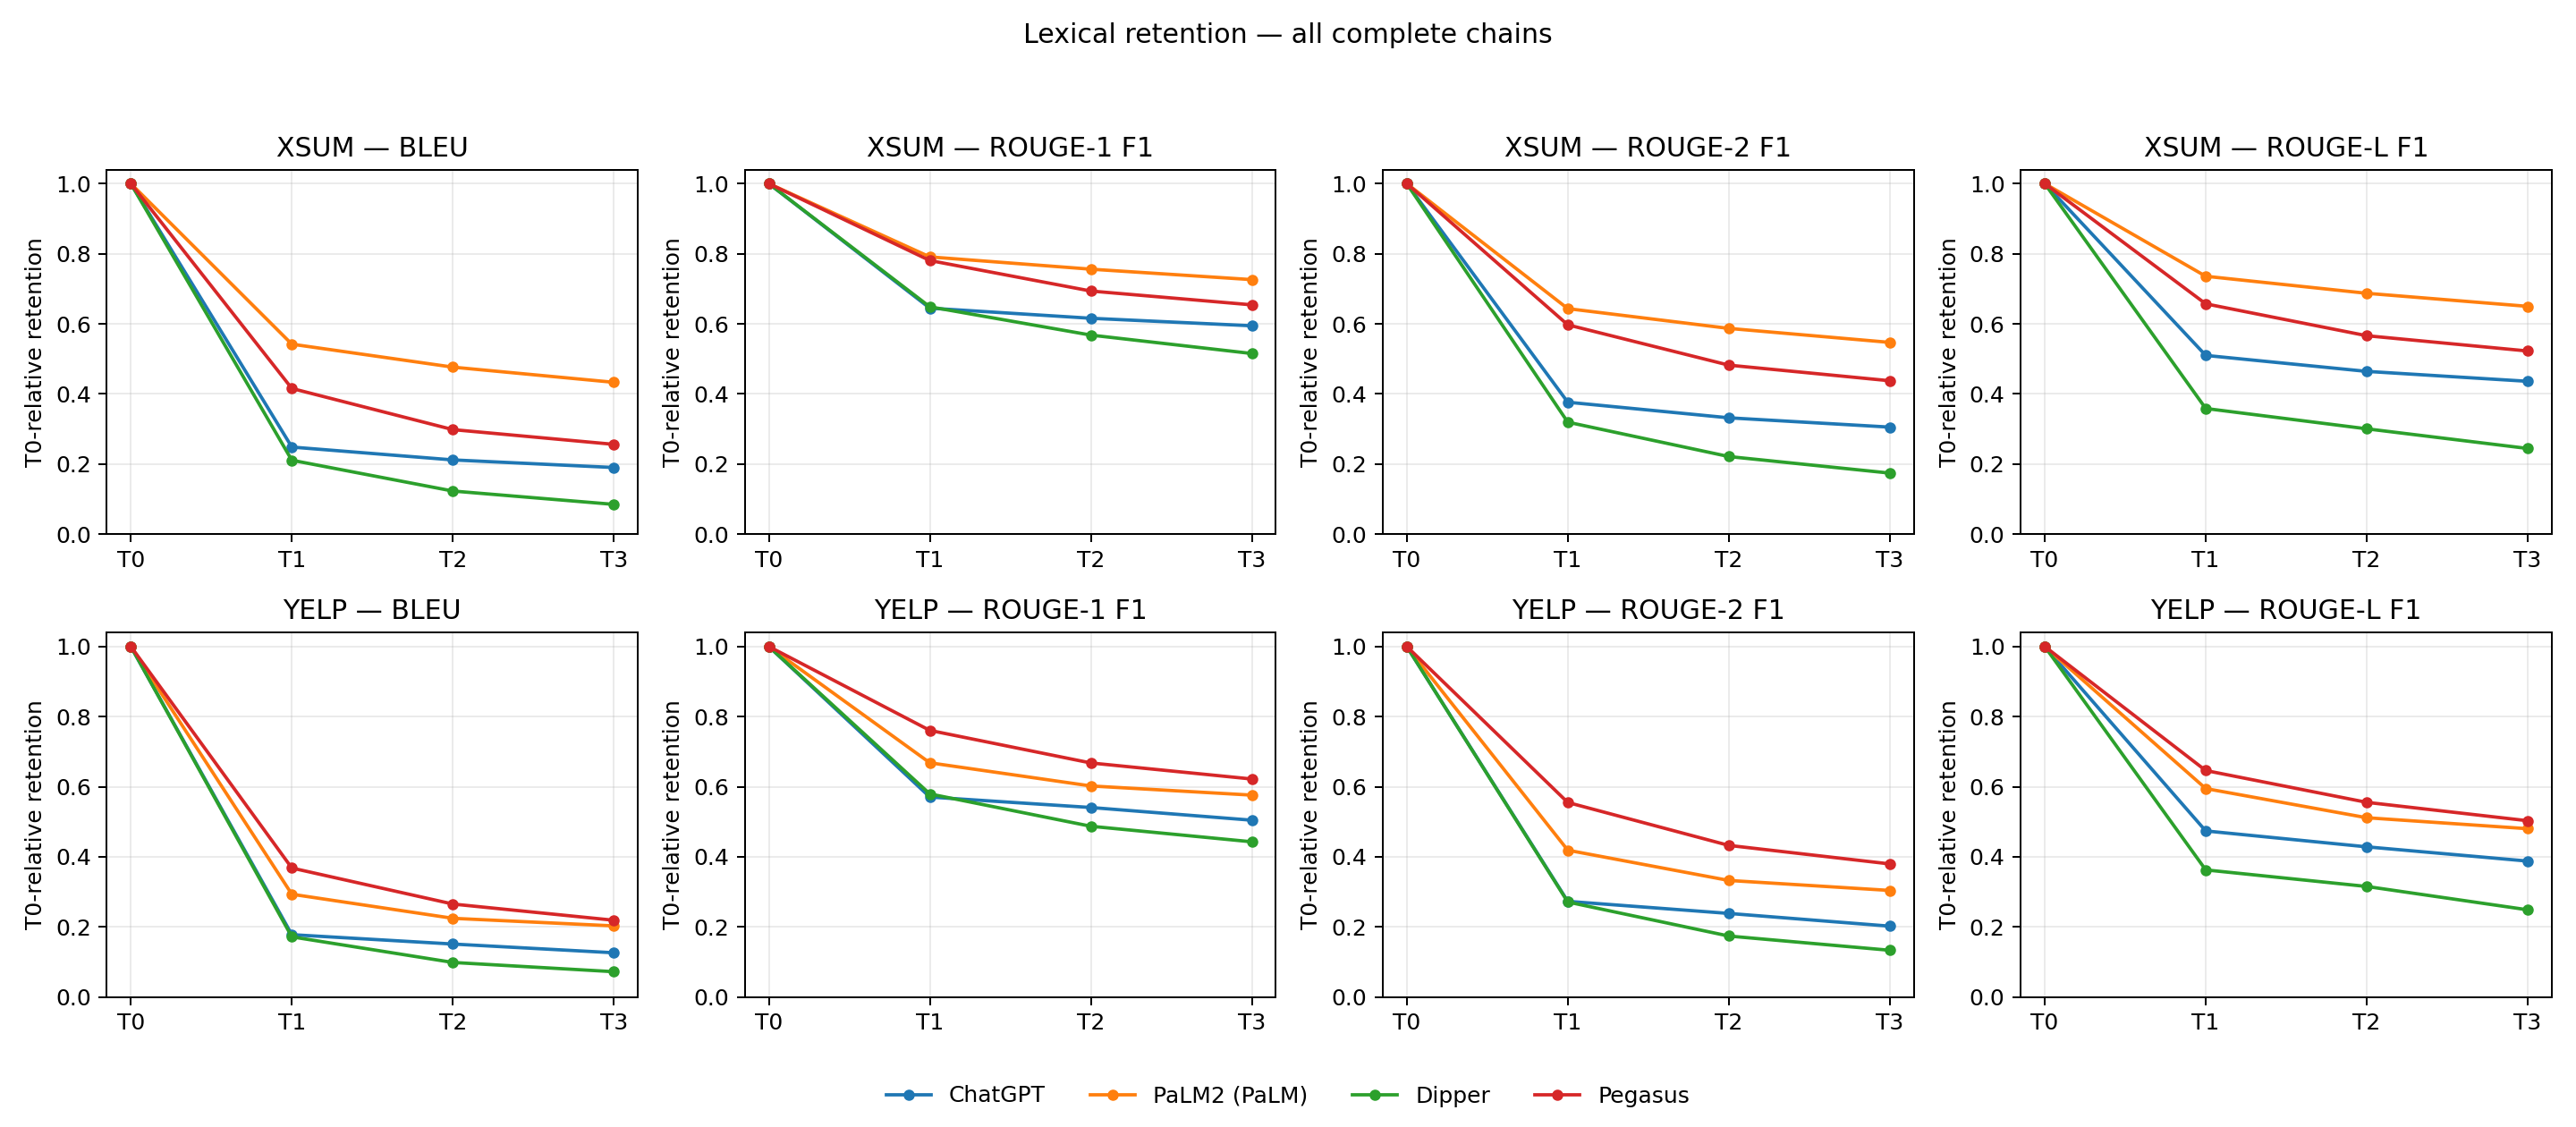

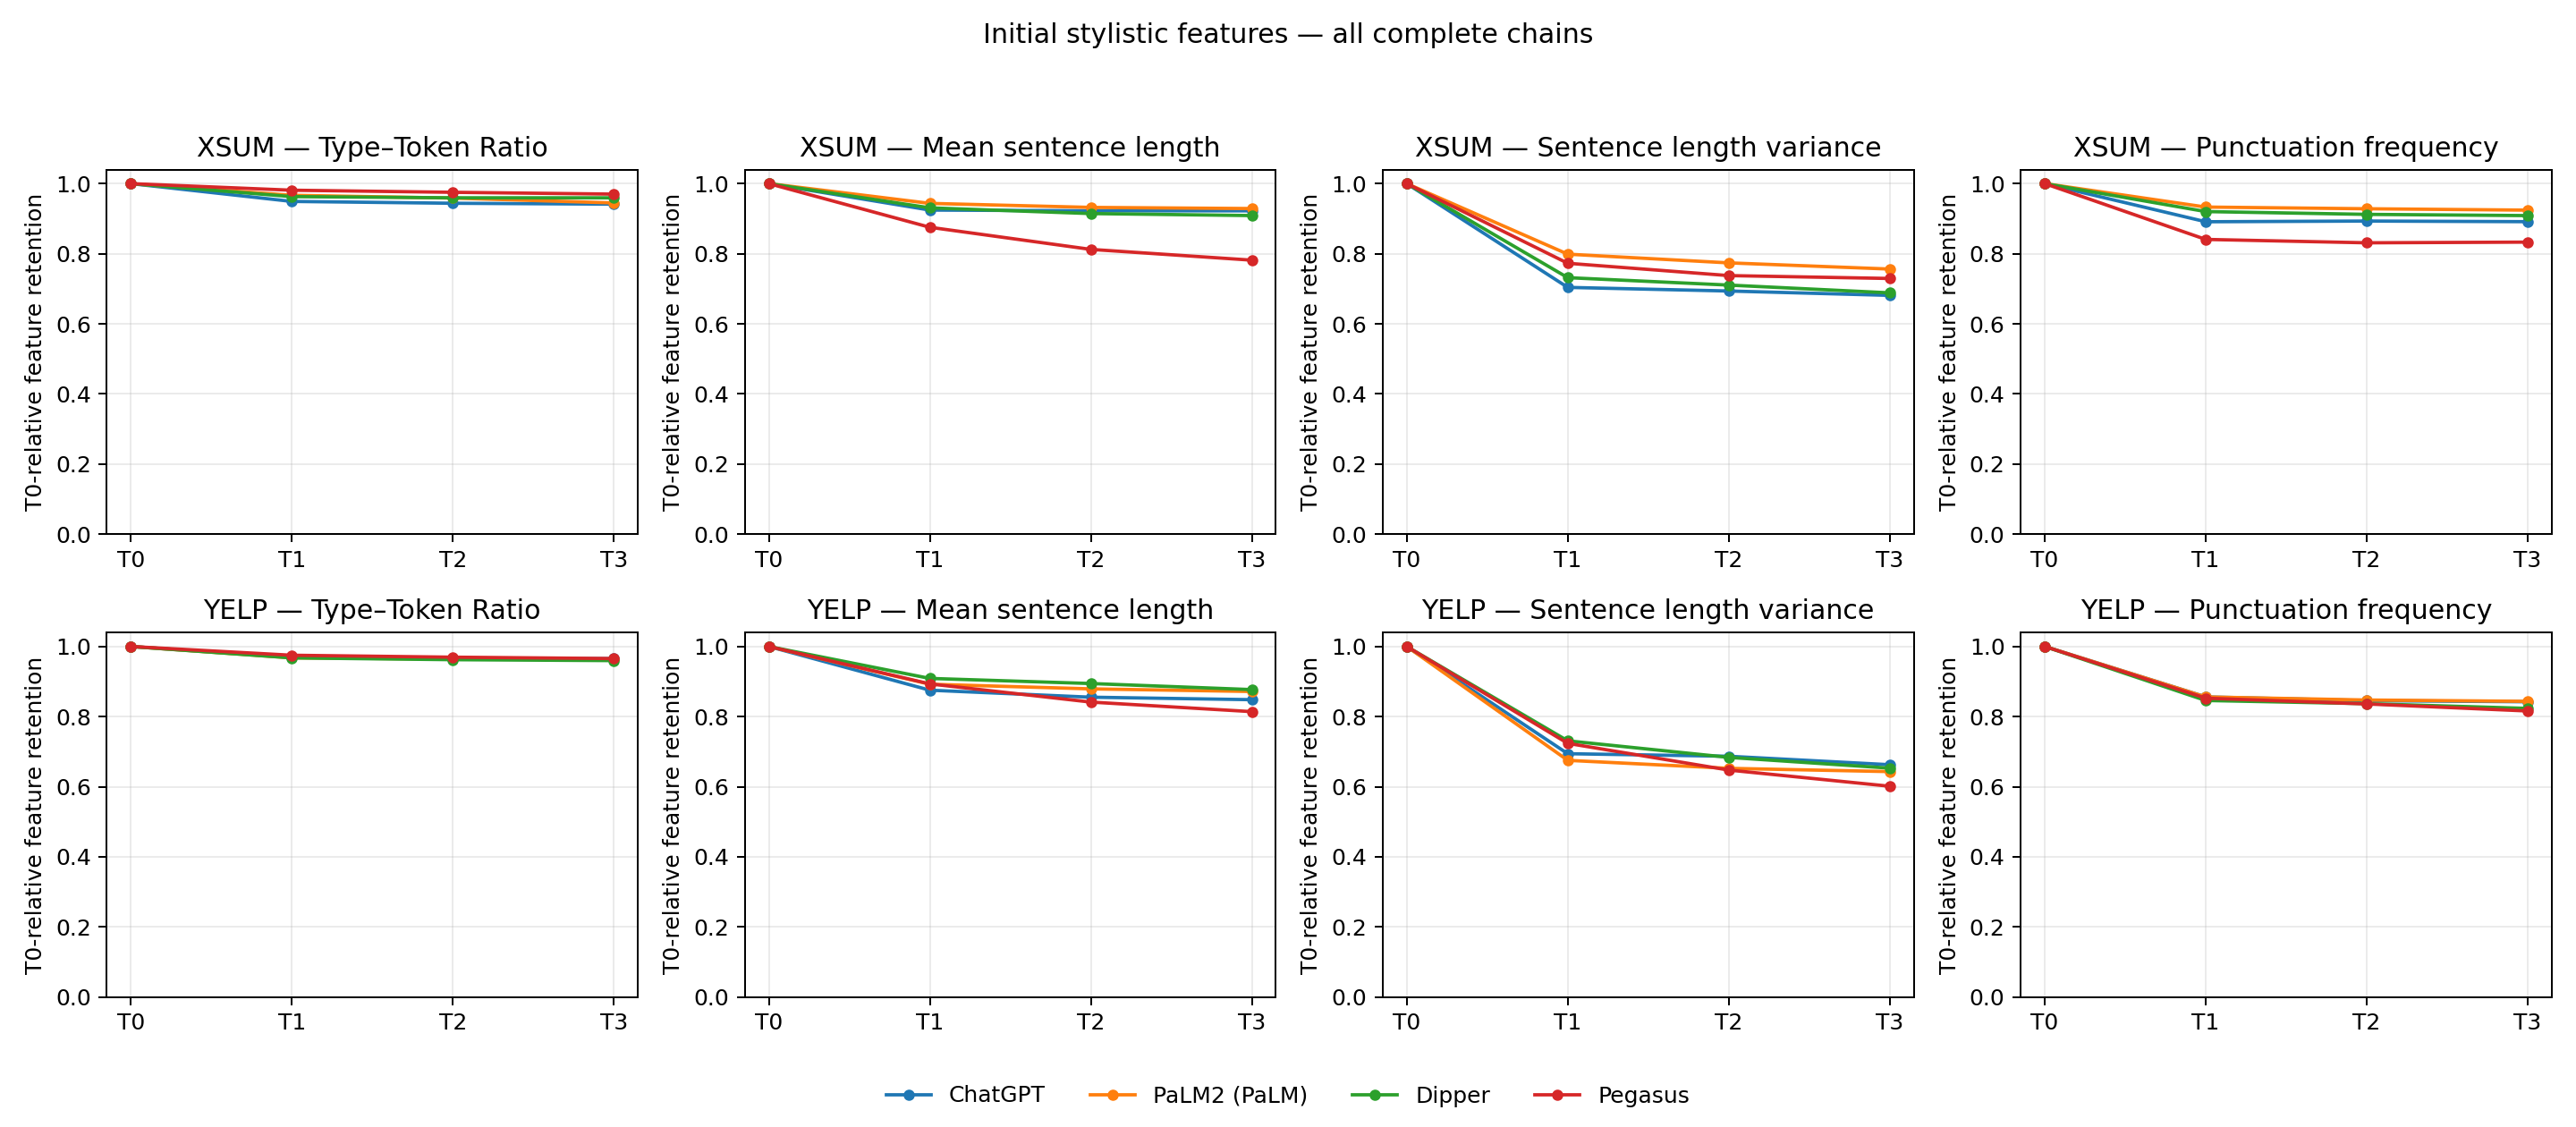

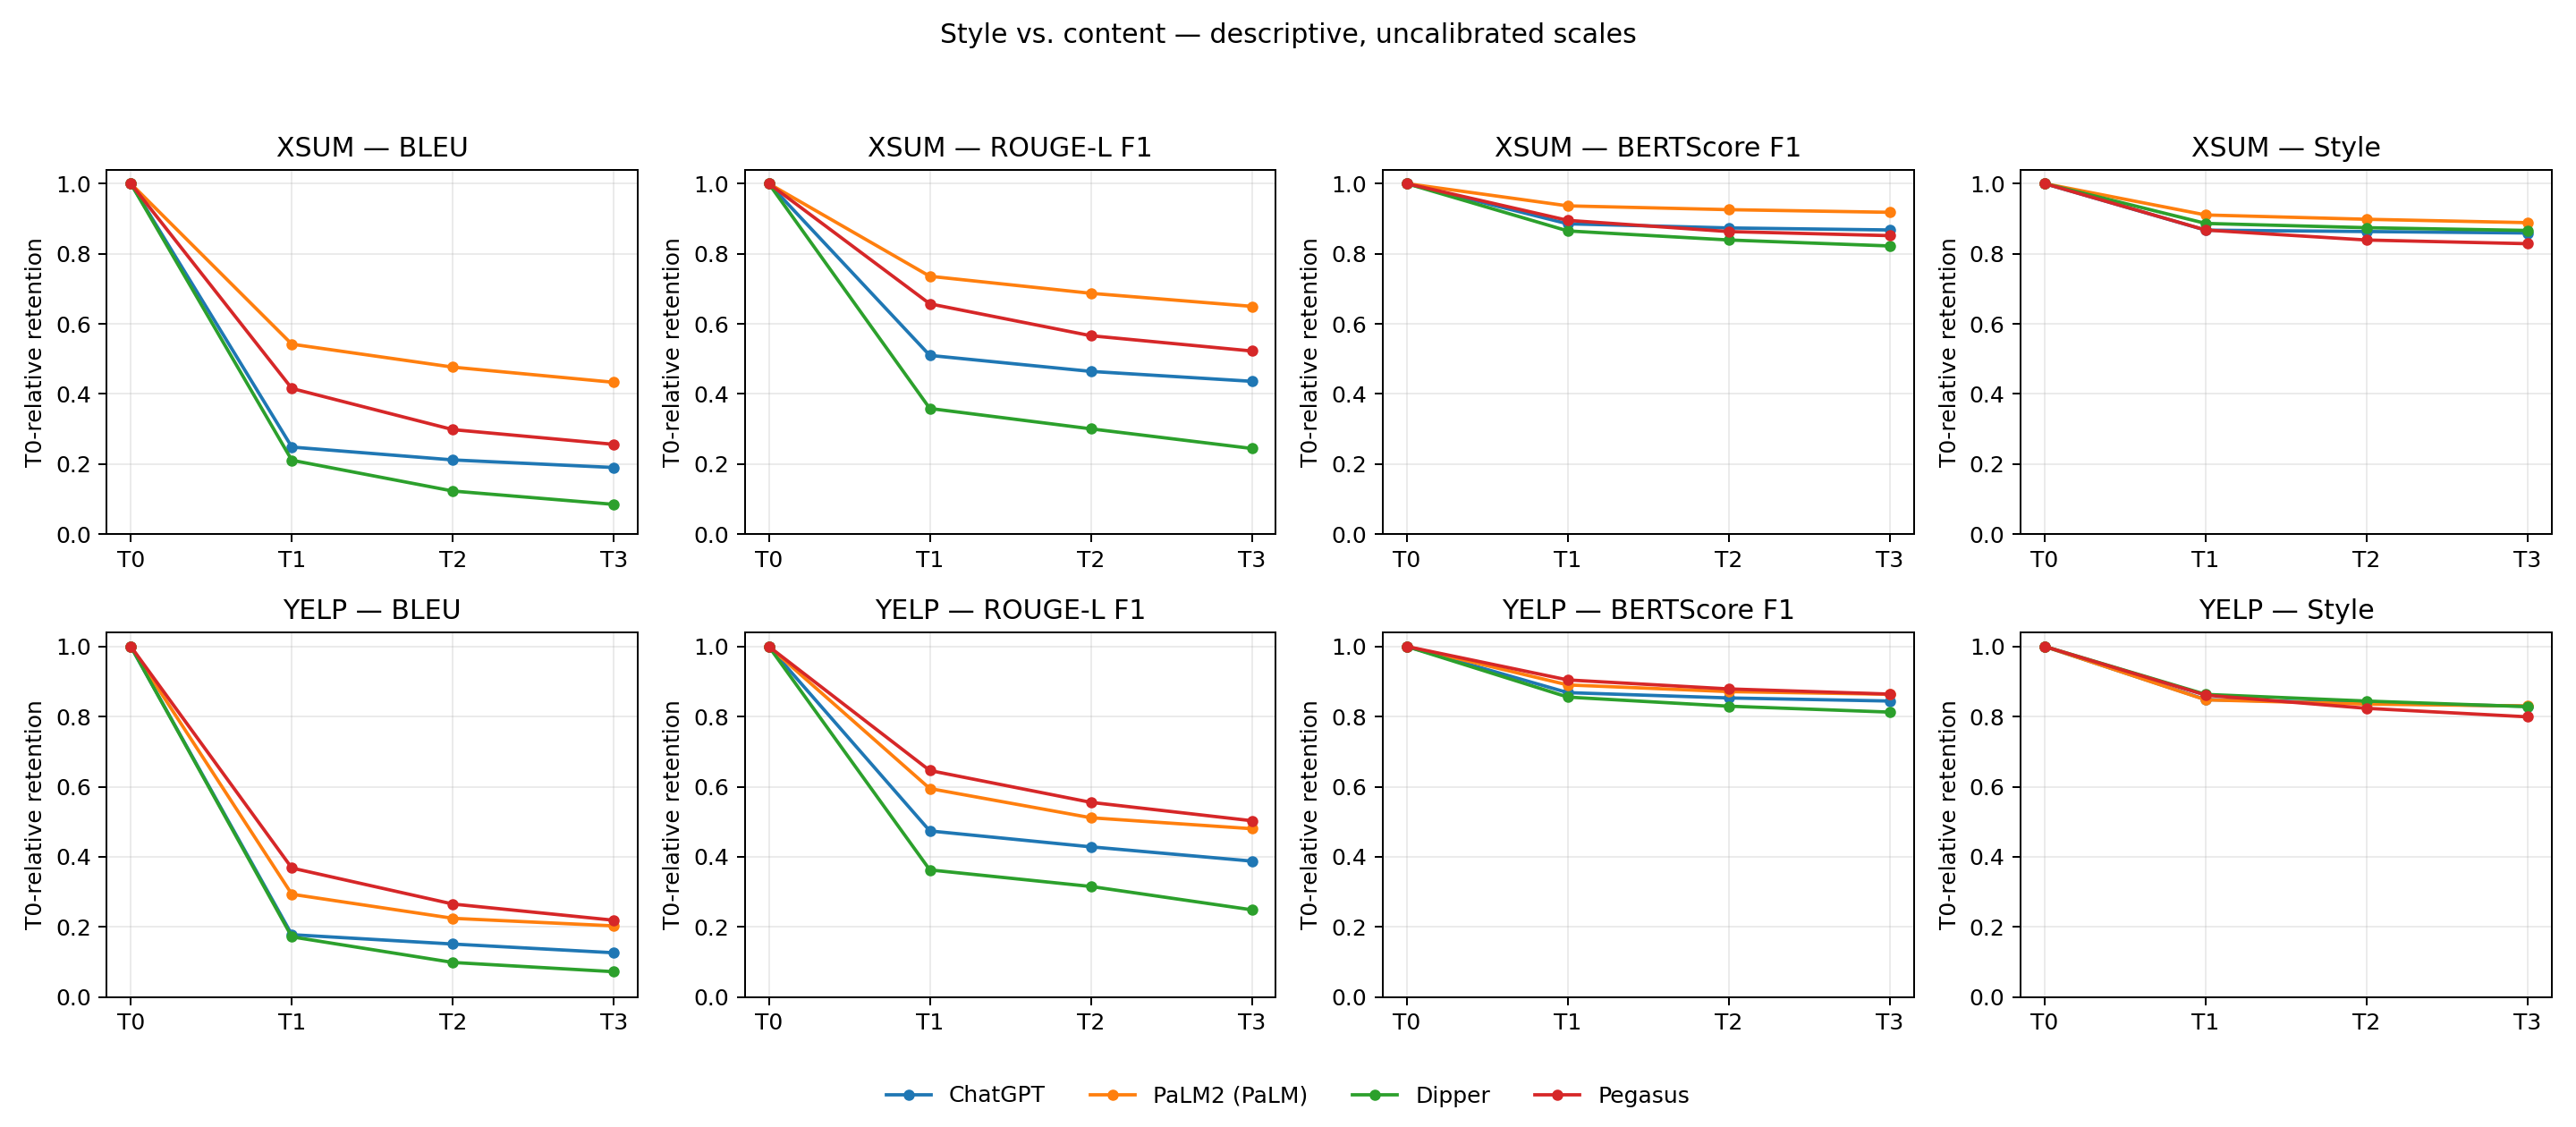

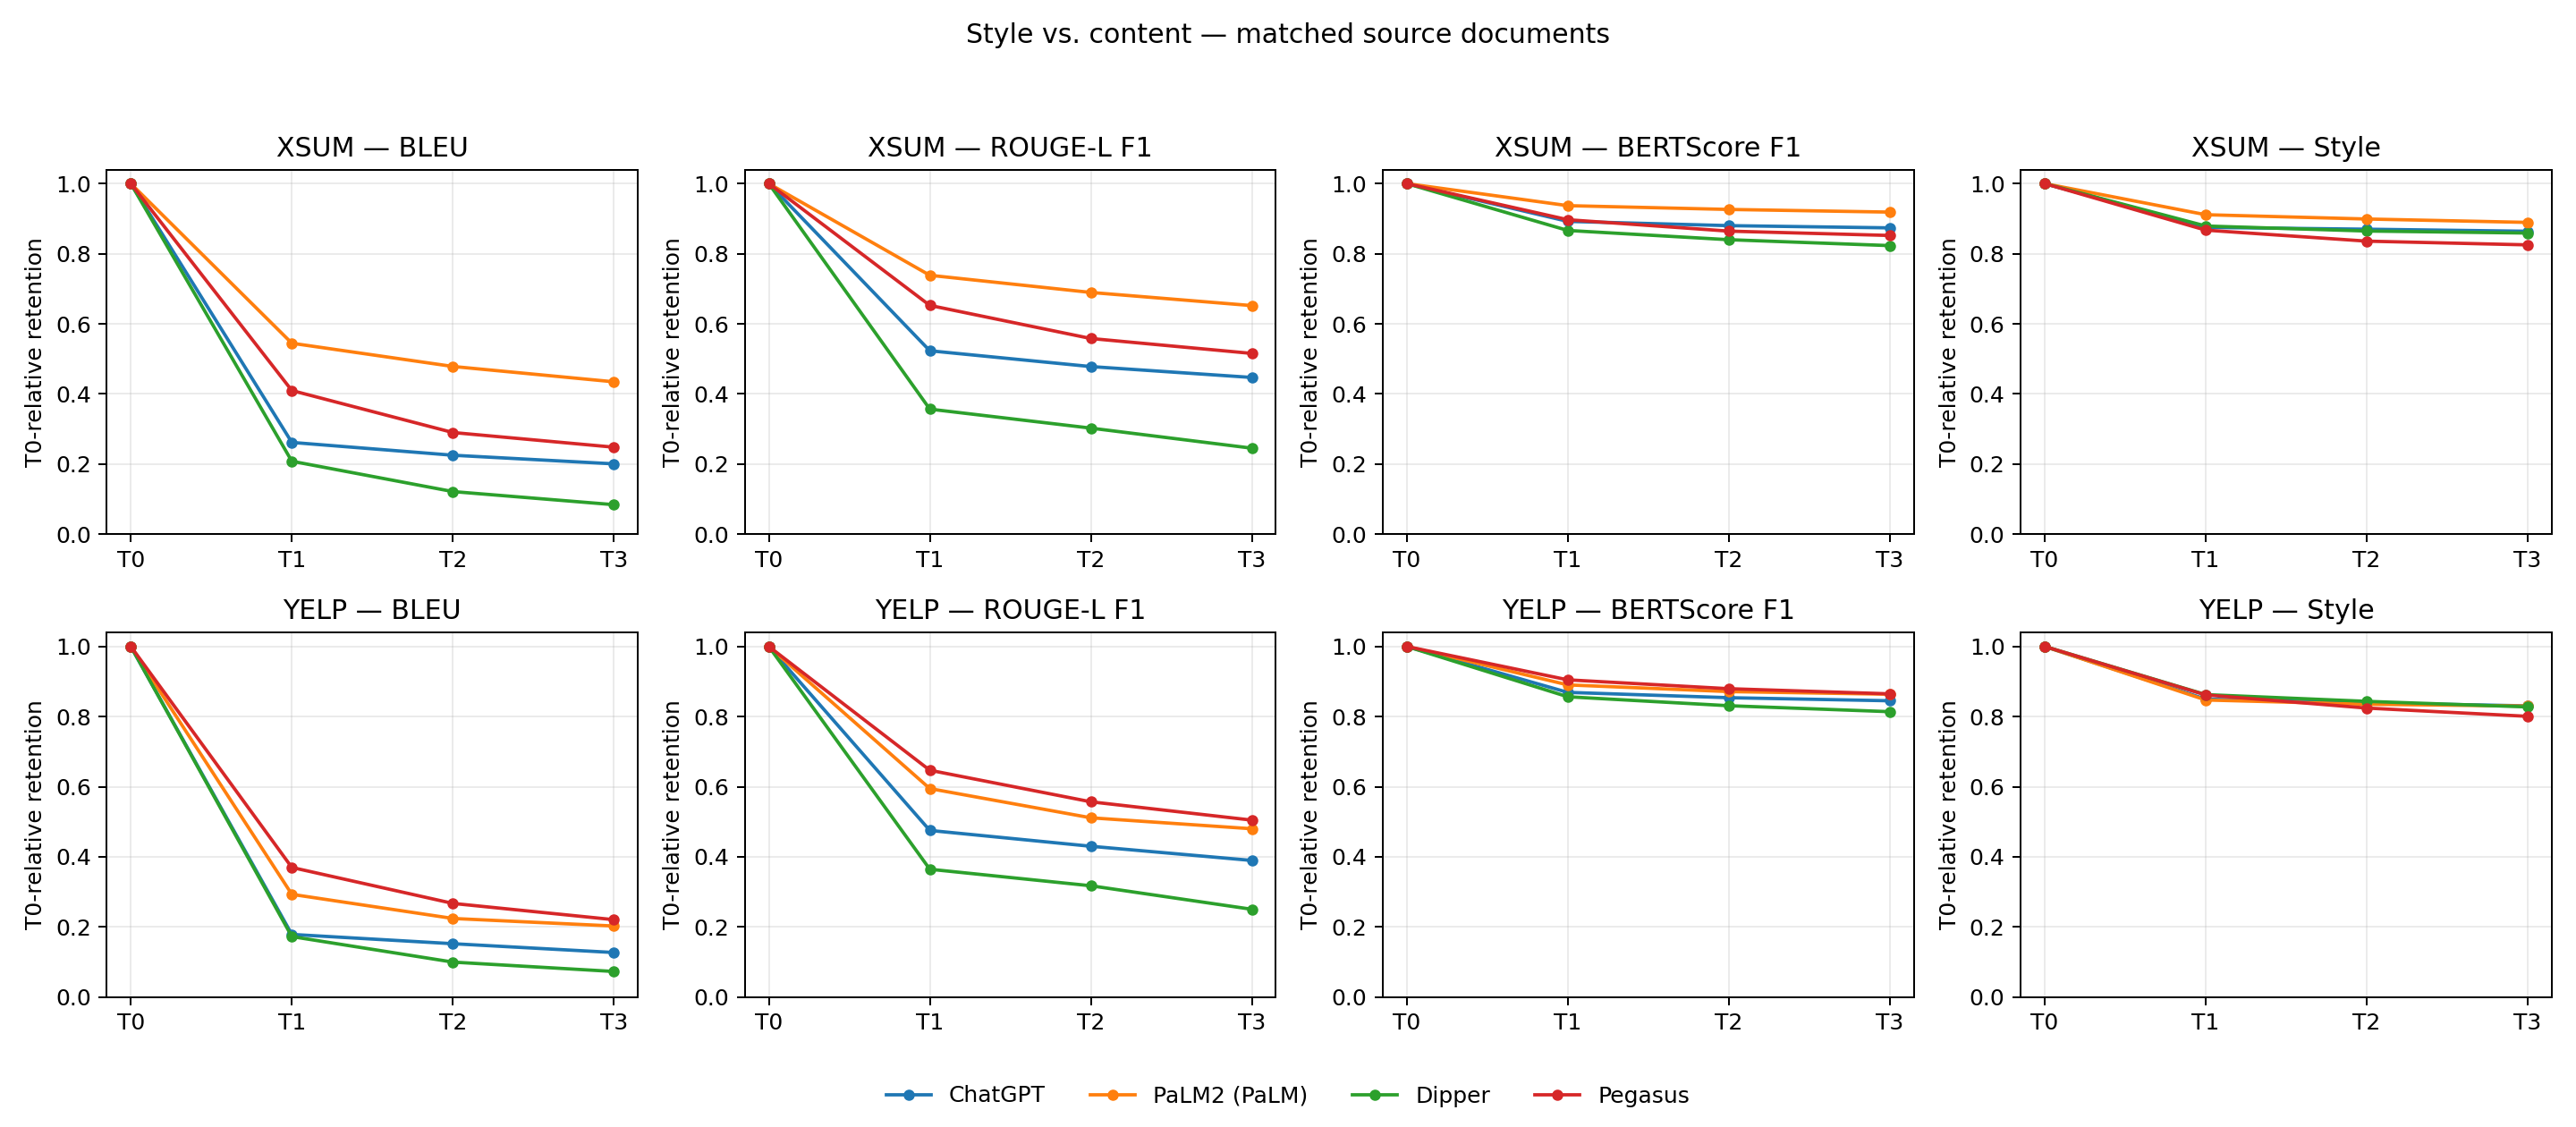

In [4]:
for name in ['update1_lexical_decay.png', 'update1_style_decay.png', 'update1_retention_comparison.png', 'update1_matched_comparison.png']:
    display(Image(filename=str(ROOT / 'figures' / name)))

## 5. Figure Interpretation and Initial Findings

The report includes matched-cohort T3 comparisons, T1–T3 changes for each model, and the limitations of comparing uncalibrated metric families.

In [5]:
report = (ROOT / 'docs/update1_style_decay.md').read_text()
# Figures have already been displayed above.
display(Markdown(chr(10).join(line for line in report.splitlines() if not line.startswith('!['))))

# Project Update 1 — Style vs. Content Decay

This analysis extends the existing similarity baseline with initial stylistic features. We compare complete Human T0 → T3 chains from Yelp and XSum for ChatGPT, PaLM, Dipper, and Pegasus(full). PaLM is displayed as PaLM2 (PaLM) in the figures to connect the project terminology with the stored corpus label; this analysis does not independently verify the underlying model version.

## 1. Analysis Scope

| dataset | paraphraser | complete_chains |
| --- | --- | --- |
| xsum | ChatGPT | 471 |
| xsum | Dipper | 476 |
| xsum | PaLM | 340 |
| xsum | Pegasus | 475 |
| yelp | ChatGPT | 488 |
| yelp | Dipper | 491 |
| yelp | PaLM | 486 |
| yelp | Pegasus | 491 |

All complete chains are retained in the main outputs. Because chain availability differs across paraphrasers, comparisons are also repeated on source documents available for all four paraphrasers: XSUM = 336, YELP = 483. Each matched source has the same T0 across models. Datasets are analyzed separately.

## 2. Initial Stylistic Features

- Type–Token Ratio: unique lowercase word tokens divided by all word tokens. Apostrophes within words are retained; numbers are excluded.
- Mean sentence length: mean word-token count across nonempty sentences.
- Sentence length variance: population variance of sentence word-token counts (ddof = 0); a single sentence has variance 0.
- Punctuation frequency: Unicode punctuation characters per 100 word tokens.

Sentence boundaries use a lightweight rule based on sentence-final punctuation followed by whitespace, or line breaks. Abbreviations and irregular punctuation can affect segmentation. TTR is sensitive to text length. These features provide initial descriptive evidence, not a validated measure of authorial identity.

## 3. T0-relative Metrics

BLEU and ROUGE-1/2/L F1 represent lexical retention. BERTScore precision/recall/F1 represent semantic similarity, with F1 used in the main figures. The supplied document-level score files are reused after exact key and coverage validation. The existing baseline defaults to distilbert-base-uncased without baseline rescaling; the supplied CSV files do not record the actual model, configuration, or package versions used, so their generation settings cannot be independently confirmed.

For similarity metrics, T0 self-similarity is set to its theoretical value of 1. Retention is S(Tg,T0) / S(T0,T0), which equals the stored score; relative change is retention − 1. T0 anchors are not newly computed BERTScore observations.

For each stylistic feature f, signed relative change is (f(Tg) − f(T0)) / f(T0). If both values are zero, change is 0; if only T0 is zero, the ratio is undefined and saved as a missing value. Per-metric counts in the summary expose these exclusions.

To include zero-baseline features in a bounded descriptive curve, feature retention is 1 − |f(Tg) − f(T0)| / (|f(Tg)| + |f(T0)|), with retention 1 when both are zero. Style retention is the unweighted mean of the four feature retentions for each chain and generation. This is an exploratory feature-preservation index. Normalization gives a common T0 anchor, but does not make BLEU, BERTScore, and style retention empirically calibrated or directly equivalent.

## 4. Decay Curves


**Figure 1.** Mean BLEU and ROUGE-1/2/L F1 relative to the original T0 text. Each row is a dataset and each line is a paraphraser. Lower values indicate less surface overlap; the same complete chains contribute at every generation within each line.


**Figure 2.** T0-relative retention of each initial stylistic feature. A lower value means the feature has moved farther from its source value in either direction. Recovery is possible, so these trajectories should not be assumed to decay monotonically.


**Figure 3.** BLEU, ROUGE-L F1, BERTScore F1, and exploratory style retention for all complete chains. Vertical differences across metric families are descriptive because their scales are not calibrated.


**Figure 4.** The same comparison restricted to source documents with complete chains for all four paraphrasers. This controls source composition within each dataset. Lines show means; uncertainty is not represented by confidence bands.

## 5. Results

T3 means on the matched cohort:

| dataset | paraphraser | bleu | rougeL_f1 | bertscore_f1 | style_retention |
| --- | --- | --- | --- | --- | --- |
| xsum | ChatGPT | 0.201 | 0.447 | 0.874 | 0.864 |
| xsum | Dipper | 0.084 | 0.245 | 0.823 | 0.859 |
| xsum | PaLM | 0.435 | 0.652 | 0.919 | 0.889 |
| xsum | Pegasus | 0.248 | 0.516 | 0.852 | 0.825 |
| yelp | ChatGPT | 0.127 | 0.390 | 0.845 | 0.831 |
| yelp | Dipper | 0.073 | 0.250 | 0.814 | 0.828 |
| yelp | PaLM | 0.203 | 0.480 | 0.864 | 0.830 |
| yelp | Pegasus | 0.221 | 0.505 | 0.865 | 0.801 |

### XSUM

ChatGPT: from T1 to T3, BLEU changes from 0.262 to 0.201, ROUGE-L F1 from 0.523 to 0.447, BERTScore F1 from 0.892 to 0.874, and exploratory style retention from 0.875 to 0.864.

PaLM: from T1 to T3, BLEU changes from 0.545 to 0.435, ROUGE-L F1 from 0.738 to 0.652, BERTScore F1 from 0.937 to 0.919, and exploratory style retention from 0.911 to 0.889.

Dipper: from T1 to T3, BLEU changes from 0.208 to 0.084, ROUGE-L F1 from 0.357 to 0.245, BERTScore F1 from 0.866 to 0.823, and exploratory style retention from 0.879 to 0.859.

Pegasus: from T1 to T3, BLEU changes from 0.410 to 0.248, ROUGE-L F1 from 0.653 to 0.516, BERTScore F1 from 0.897 to 0.852, and exploratory style retention from 0.867 to 0.825.

At T3, BERTScore F1 ranks PaLM > ChatGPT > Pegasus > Dipper on the matched sources. This describes this metric and sample, rather than overall paraphraser quality.

### YELP

ChatGPT: from T1 to T3, BLEU changes from 0.179 to 0.127, ROUGE-L F1 from 0.475 to 0.390, BERTScore F1 from 0.869 to 0.845, and exploratory style retention from 0.850 to 0.831.

PaLM: from T1 to T3, BLEU changes from 0.293 to 0.203, ROUGE-L F1 from 0.595 to 0.480, BERTScore F1 from 0.890 to 0.864, and exploratory style retention from 0.847 to 0.830.

Dipper: from T1 to T3, BLEU changes from 0.172 to 0.073, ROUGE-L F1 from 0.365 to 0.250, BERTScore F1 from 0.857 to 0.814, and exploratory style retention from 0.863 to 0.828.

Pegasus: from T1 to T3, BLEU changes from 0.370 to 0.221, ROUGE-L F1 from 0.647 to 0.505, BERTScore F1 from 0.905 to 0.865, and exploratory style retention from 0.862 to 0.801.

At T3, BERTScore F1 ranks Pegasus > PaLM > ChatGPT > Dipper on the matched sources. This describes this metric and sample, rather than overall paraphraser quality.

### Initial Stylistic Patterns

XSUM: across the four paraphrasers at T3, TTR retention ranges from 0.941 to 0.970, mean sentence length retention from 0.782 to 0.929, sentence length variance retention from 0.681 to 0.756, and punctuation retention from 0.833 to 0.924. These values use all complete chains, as in Figure 2.

YELP: across the four paraphrasers at T3, TTR retention ranges from 0.960 to 0.966, mean sentence length retention from 0.814 to 0.877, sentence length variance retention from 0.601 to 0.663, and punctuation retention from 0.816 to 0.844. These values use all complete chains, as in Figure 2.

Sentence length variance shows the largest departure under this feature-distance definition, while TTR stays closest to its source value. Variance is sensitive to sentence segmentation and zero baselines, so this difference requires follow-up before being interpreted as a robust stylistic effect.

## 6. Initial Interpretation

At T3, BERTScore F1 is numerically higher than ROUGE-L F1 in 8 of 8 matched dataset/paraphraser groups and higher than the exploratory style index in 6 of 8 groups. The curves are consistent with substantial surface rewriting while semantic similarity remains comparatively high. This supports a preliminary hypothesis that semantic content may be more stable than lexical form under these metrics.

The stronger claim that semantics lasts longer than style is not established. Raw BERTScore has a different score distribution from lexical overlap, and the style index depends on a chosen distance formula and four equally weighted features. T0 normalization alone cannot resolve these differences. A high style index can also conceal substantial changes in features not measured here. Decline relative to T0 is evidence of change, not proof of a loss of authorial identity.

## 7. Limitations and Next Steps

- Treat the stylistic features as an initial analysis. Add length-controlled lexical diversity, richer syntactic features, and authorship attribution before making claims about identity loss.
- Validate semantic retention using human judgments or controlled meaning-change examples, and record the BERTScore model and configuration when regenerating scores.
- Use source-level paired bootstrap intervals for model comparisons; the present means and standard deviations do not establish statistical significance.
- Inspect signed feature changes alongside bounded retention. An increase in sentence length or TTR is still a departure from T0, and zero baselines require explicit handling.
- Retain the matched-source sensitivity analysis because complete-chain counts differ across models, especially for XSum PaLM.

## 6. Validation

In [6]:
assert len(details) == 4 * len(pd.read_csv(ROOT / 'data/processed/update1_processed.csv'))
assert not details.duplicated(['dataset', 'key', 'source', 'paraphraser', 'generation']).any()
assert details.loc[details.generation.eq('t0'), LEXICAL + SEMANTIC + ['style_retention']].eq(1).all().all()
assert details[LEXICAL + SEMANTIC + ['style_retention']].notna().all().all()
print('Coverage, uniqueness, and T0 anchors validated.')

Coverage, uniqueness, and T0 anchors validated.
